In [1]:
# Adapted from https://www.kaggle.com/code/ruchitass/predicting-stress-a-machine-learning-approach

In [1]:
!python --version

Python 3.10.12


In [4]:
import mlflow

In [3]:
mlflow.__version__

'2.14.2'

In [6]:
!pwd

/app


In [7]:
!ls /app

Dockerfile  Pipfile.lock  kaggle.json
Pipfile     README.md	  stress_prediction_notebook.ipynb


In [8]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
# import seaborn as sns

import nltk
import re

# Download the stopwords resource
nltk.download('stopwords')

stemmer = nltk.SnowballStemmer("english")

from wordcloud import STOPWORDS
from PIL import Image
from wordcloud import WordCloud

# from textblob import TextBlob
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

import kaggle
# import nltk
# import re
# stemmer = nltk.SnowballStemmer("english")
from nltk.corpus import stopwords
stopwords = stopwords.words('english')
# import string

import matplotlib.pyplot as plt
import numpy as np


from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
# import warnings
# warnings.filterwarnings("ignore")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [11]:
!ls -a

.		    Dockerfile	  README.md
..		    Pipfile	  kaggle.json
.ipynb_checkpoints  Pipfile.lock  stress_prediction_notebook.ipynb


In [12]:
!kaggle datasets download -d ruchi798/stress-analysis-in-social-media

Dataset URL: https://www.kaggle.com/datasets/ruchi798/stress-analysis-in-social-media
License(s): other
 76%|█████████████████████████████         | 1.00M/1.31M [00:00<00:00, 2.19MB/s]
100%|██████████████████████████████████████| 1.31M/1.31M [00:00<00:00, 2.62MB/s]


In [14]:
!ls

Dockerfile    kaggle.json
Pipfile       stress-analysis-in-social-media.zip
Pipfile.lock  stress_prediction_notebook.ipynb
README.md


In [13]:
#Use this if in Ubuntu machine
!mv stress-analysis-in-social-media.zip ../../data/

mv: cannot create regular file '../../data/': Not a directory


In [10]:
!unzip ../../data/stress-analysis-in-social-media.zip -d ../../data/ 

Archive:  ../../data/stress-analysis-in-social-media.zip
  inflating: ../../data/dreaddit-test.csv  
  inflating: ../../data/dreaddit-train.csv  


In [11]:
!rm ../../data/stress-analysis-in-social-media.zip 

  Preparing metadata (setup.py) ... done
  DEPRECATION: Building 'unzip' using the legacy setup.py bdist_wheel mechanism, which will be removed in a future version. pip 25.3 will enforce this behaviour change. A possible replacement is to use the standardized build interface by setting the `--use-pep517` option, (possibly combined with `--no-build-isolation`), or adding a `pyproject.toml` file to the source tree of 'unzip'. Discussion can be found at https://github.com/pypa/pip/issues/6334
  Created wheel for unzip: filename=unzip-1.0.0-py3-none-any.whl size=1298 sha256=285fa7af3b0deeff5cf2027fe595b1ada55362de0a6267dbf384953d2a8e2715
  Stored in directory: /tmp/pip-ephem-wheel-cache-itz1rxgr/wheels/80/dc/7a/f8af45bc239e7933509183f038ea8d46f3610aab82b35369f4
Successfully built unzip


In [22]:
#Use this in docker to fix some issues
#!mkdir data
#!mv stress-analysis-in-social-media.zip data/
#!unzip data/stress-analysis-in-social-media.zip -d data/
#!rm data/stress-analysis-in-social-media.zip 
# train = pd.read_csv("data/dreaddit-train.csv")
# test = pd.read_csv("data/dreaddit-test.csv")
# Please note that you will have to include unzip in the docker container if you want to run this with docker container 

In [12]:
train = pd.read_csv("../../data/dreaddit-train.csv")
test = pd.read_csv("../../data/dreaddit-test.csv")

In [23]:
train["subreddit"].unique()

array(['ptsd', 'assistance', 'relationships', 'survivorsofabuse',
       'domesticviolence', 'anxiety', 'homeless', 'stress',
       'almosthomeless', 'food_pantry'], dtype=object)

In [24]:
train

,subreddit,post_id,sentence_range,text,id,label,confidence,social_timestamp,social_karma,syntax_ari,...,lex_dal_min_pleasantness,lex_dal_min_activation,lex_dal_min_imagery,lex_dal_avg_activation,lex_dal_avg_imagery,lex_dal_avg_pleasantness,social_upvote_ratio,social_num_comments,syntax_fk_grade,sentiment
0,ptsd,8601tu,"(15, 20)","He said he had not felt that way before, sugge...",33181,1,0.800000,1521614353,5,1.806818,...,1.0000,1.1250,1.0,1.77000,1.52211,1.89556,0.86,1,3.253573,-0.002742
1,assistance,8lbrx9,"(0, 5)","Hey there r/assistance, Not sure if this is th...",2606,0,1.000000,1527009817,4,9.429737,...,1.1250,1.0000,1.0,1.69586,1.62045,1.88919,0.65,2,8.828316,0.292857
2,ptsd,9ch1zh,"(15, 20)",My mom then hit me with the newspaper and it s...,38816,1,0.800000,1535935605,2,7.769821,...,1.0000,1.1429,1.0,1.83088,1.58108,1.85828,0.67,0,7.841667,0.011894
3,relationships,7rorpp,"[5, 10]","until i met my new boyfriend, he is amazing, h...",239,1,0.600000,1516429555,0,2.667798,...,1.0000,1.1250,1.0,1.75356,1.52114,1.98848,0.50,5,4.104027,0.141671
4,survivorsofabuse,9p2gbc,"[0, 5]",October is Domestic Violence Awareness Month a...,1421,1,0.800000,1539809005,24,7.554238,...,1.0000,1.1250,1.0,1.77644,1.64872,1.81456,1.00,1,7.910952,-0.204167
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2833,relationships,7oee1t,"[35, 40]","* Her, a week ago: Precious, how are you? (I i...",1713,0,1.000000,1515187044,13,-1.369333,...,1.4000,1.0000,1.0,1.71133,1.45301,2.00304,0.84,16,0.254444,0.552066
2834,ptsd,9p4ung,"[20, 25]",I don't have the ability to cope with it anymo...,1133,1,1.000000,1539827412,33,9.425478,...,1.0000,1.0000,1.0,1.65003,1.56842,1.81527,0.96,6,8.640664,-0.220370
2835,anxiety,9nam6l,"(5, 10)",In case this is the first time you're reading ...,10442,0,1.000000,1539269312,2,11.060675,...,1.1250,1.1250,1.0,1.79768,1.49074,1.92286,1.00,1,9.951524,0.045455
2836,almosthomeless,5y53ya,"[5, 10]",Do you find this normal? They have a good rela...,1834,0,0.571429,1488938143,4,2.421912,...,1.1111,1.1429,1.0,1.71642,1.57627,1.89972,0.75,7,4.036765,0.159722


In [25]:
print("Rows :", train.shape[0])

Rows : 2838


In [26]:
print("Columns :", train.shape[1])

Columns : 116


In [27]:
print(train.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2838 entries, 0 to 2837
Columns: 116 entries, subreddit to sentiment
dtypes: float64(106), int64(6), object(4)
memory usage: 2.5+ MB
None


In [28]:
print(train.select_dtypes(include=['object']).apply(pd.Series.nunique, axis=0))

subreddit           10
post_id           2343
sentence_range     173
text              2820
dtype: int64


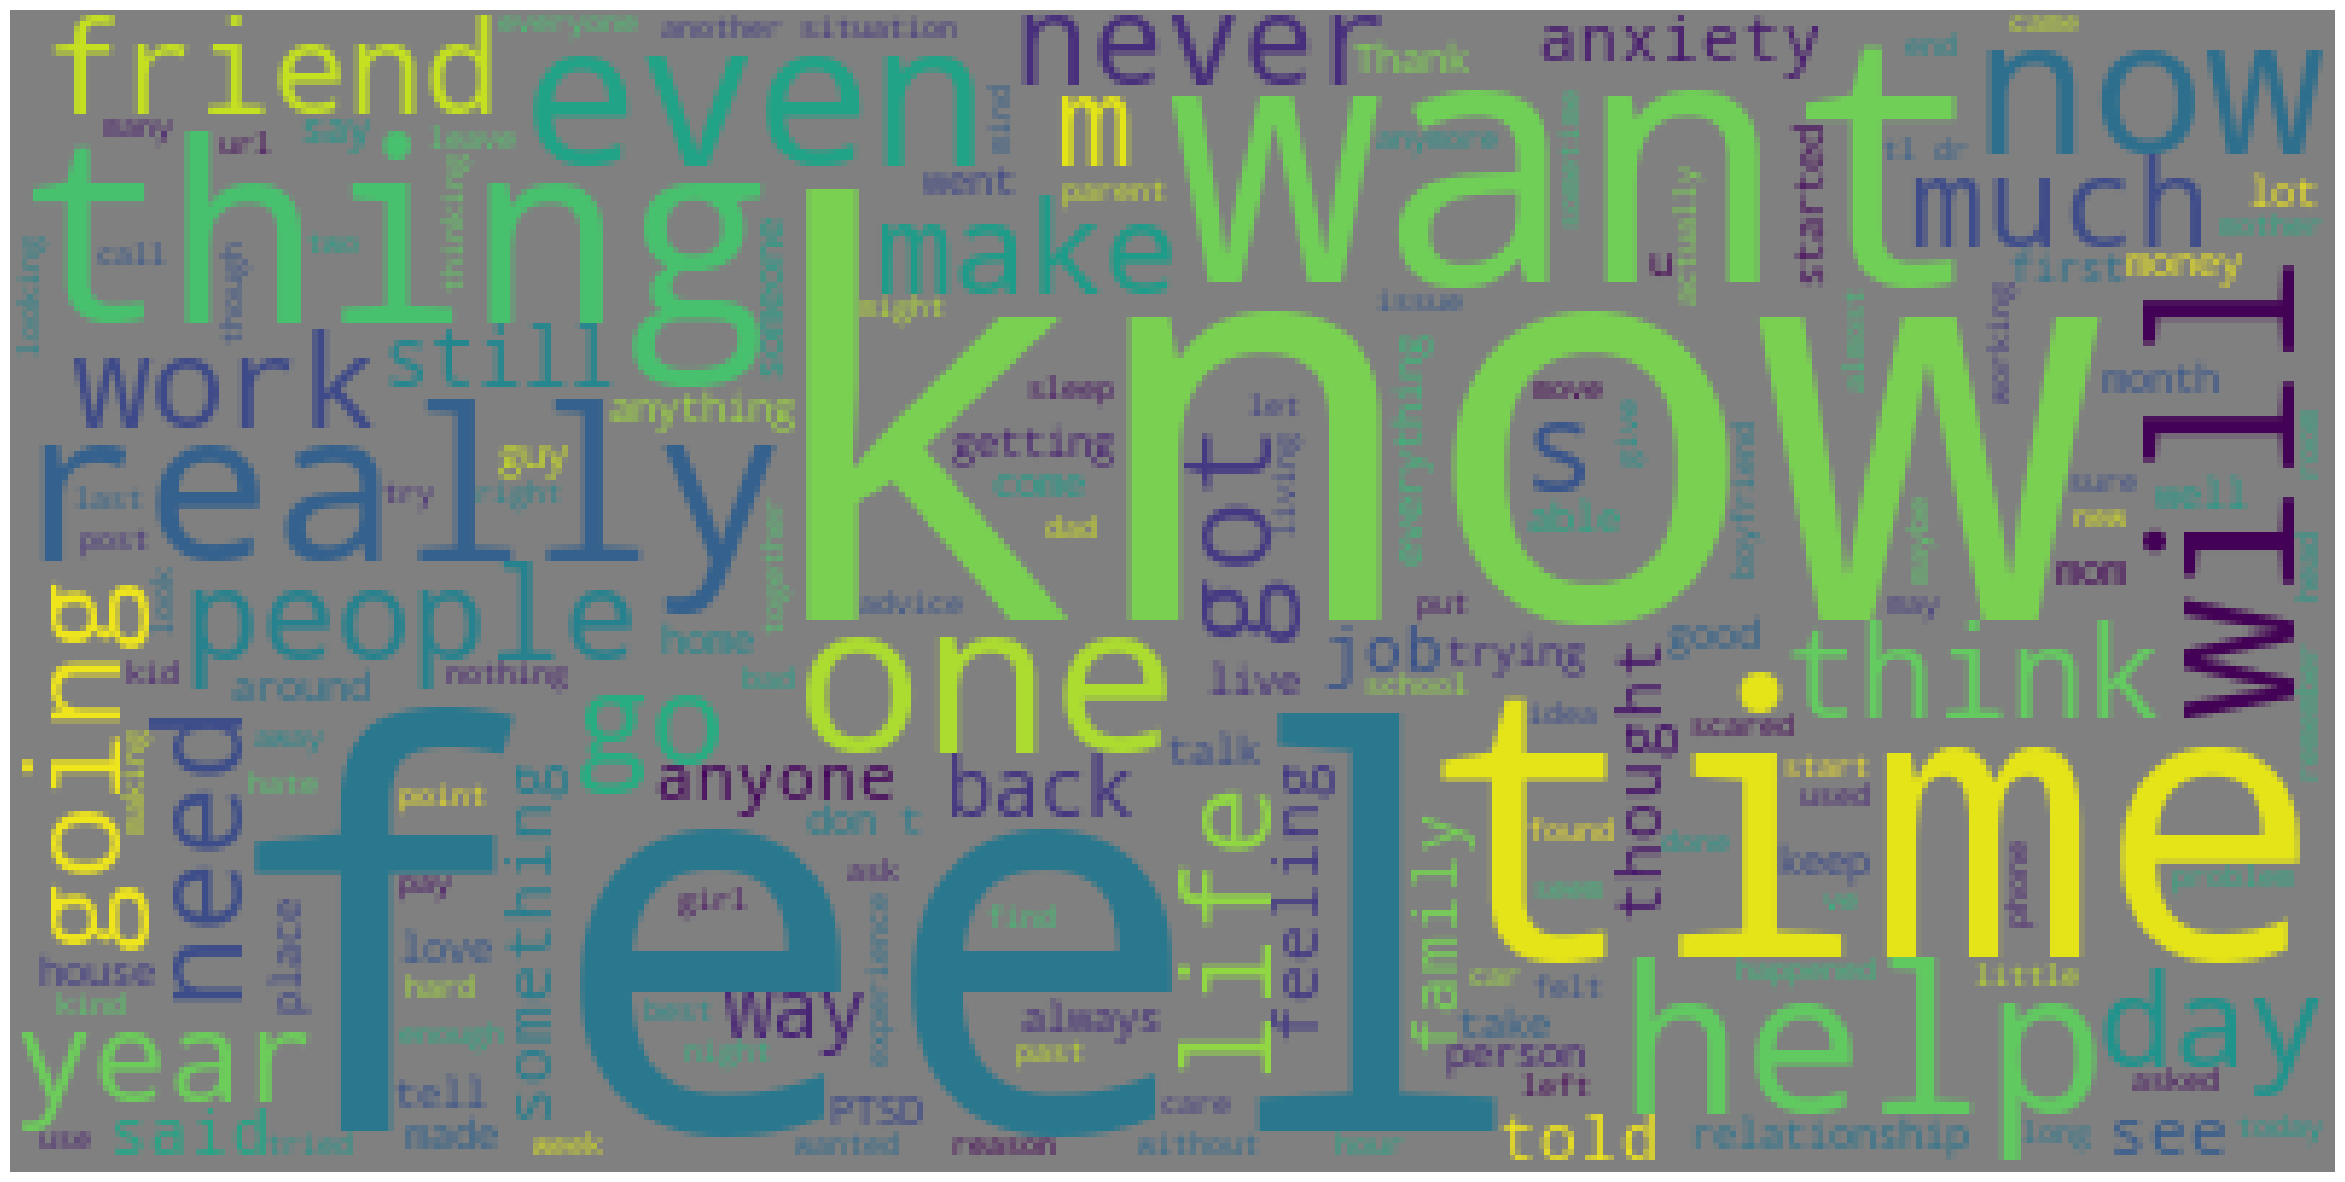

In [68]:
#Wordcloud
def wc(data,bgcolor):
    plt.figure(figsize=(30,30))
    #mask=np.array(Image.open('/kaggle/input/stressanalysisinsocialmedia/stress-954814_960_720.png'))
    wc=WordCloud(background_color=bgcolor,stopwords=STOPWORDS)
    wc.generate(' '.join(data))
    plt.imshow(wc)
    plt.axis("off")
wc(train.text,'grey')

In [29]:
categorical_columns = list(train.select_dtypes(include=['object']).columns)

In [30]:
numerical_columns = [column for column in train.columns if column not in categorical_columns and column not in ['label']]

In [31]:
numerical_columns

['id',
 'confidence',
 'social_timestamp',
 'social_karma',
 'syntax_ari',
 'lex_liwc_WC',
 'lex_liwc_Analytic',
 'lex_liwc_Clout',
 'lex_liwc_Authentic',
 'lex_liwc_Tone',
 'lex_liwc_WPS',
 'lex_liwc_Sixltr',
 'lex_liwc_Dic',
 'lex_liwc_function',
 'lex_liwc_pronoun',
 'lex_liwc_ppron',
 'lex_liwc_i',
 'lex_liwc_we',
 'lex_liwc_you',
 'lex_liwc_shehe',
 'lex_liwc_they',
 'lex_liwc_ipron',
 'lex_liwc_article',
 'lex_liwc_prep',
 'lex_liwc_auxverb',
 'lex_liwc_adverb',
 'lex_liwc_conj',
 'lex_liwc_negate',
 'lex_liwc_verb',
 'lex_liwc_adj',
 'lex_liwc_compare',
 'lex_liwc_interrog',
 'lex_liwc_number',
 'lex_liwc_quant',
 'lex_liwc_affect',
 'lex_liwc_posemo',
 'lex_liwc_negemo',
 'lex_liwc_anx',
 'lex_liwc_anger',
 'lex_liwc_sad',
 'lex_liwc_social',
 'lex_liwc_family',
 'lex_liwc_friend',
 'lex_liwc_female',
 'lex_liwc_male',
 'lex_liwc_cogproc',
 'lex_liwc_insight',
 'lex_liwc_cause',
 'lex_liwc_discrep',
 'lex_liwc_tentat',
 'lex_liwc_certain',
 'lex_liwc_differ',
 'lex_liwc_percept

In [32]:
categorical_columns = [column for column in categorical_columns if column != 'text'] 

In [33]:
categorical_columns

['subreddit', 'post_id', 'sentence_range']

In [34]:
train[categorical_columns]

,subreddit,post_id,sentence_range
0,ptsd,8601tu,"(15, 20)"
1,assistance,8lbrx9,"(0, 5)"
2,ptsd,9ch1zh,"(15, 20)"
3,relationships,7rorpp,"[5, 10]"
4,survivorsofabuse,9p2gbc,"[0, 5]"
...,...,...,...
2833,relationships,7oee1t,"[35, 40]"
2834,ptsd,9p4ung,"[20, 25]"
2835,anxiety,9nam6l,"(5, 10)"
2836,almosthomeless,5y53ya,"[5, 10]"


In [35]:
train[numerical_columns]

,id,confidence,social_timestamp,social_karma,syntax_ari,lex_liwc_WC,lex_liwc_Analytic,lex_liwc_Clout,lex_liwc_Authentic,lex_liwc_Tone,...,lex_dal_min_pleasantness,lex_dal_min_activation,lex_dal_min_imagery,lex_dal_avg_activation,lex_dal_avg_imagery,lex_dal_avg_pleasantness,social_upvote_ratio,social_num_comments,syntax_fk_grade,sentiment
0,33181,0.800000,1521614353,5,1.806818,116,72.64,15.04,89.26,1.00,...,1.0000,1.1250,1.0,1.77000,1.52211,1.89556,0.86,1,3.253573,-0.002742
1,2606,1.000000,1527009817,4,9.429737,109,79.08,76.85,56.75,98.18,...,1.1250,1.0000,1.0,1.69586,1.62045,1.88919,0.65,2,8.828316,0.292857
2,38816,0.800000,1535935605,2,7.769821,167,33.80,76.38,86.24,25.77,...,1.0000,1.1429,1.0,1.83088,1.58108,1.85828,0.67,0,7.841667,0.011894
3,239,0.600000,1516429555,0,2.667798,273,2.98,15.25,95.42,79.26,...,1.0000,1.1250,1.0,1.75356,1.52114,1.98848,0.50,5,4.104027,0.141671
4,1421,0.800000,1539809005,24,7.554238,89,32.22,28.71,84.01,1.00,...,1.0000,1.1250,1.0,1.77644,1.64872,1.81456,1.00,1,7.910952,-0.204167
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2833,1713,1.000000,1515187044,13,-1.369333,89,19.41,99.00,37.57,99.00,...,1.4000,1.0000,1.0,1.71133,1.45301,2.00304,0.84,16,0.254444,0.552066
2834,1133,1.000000,1539827412,33,9.425478,135,40.97,4.45,98.01,1.00,...,1.0000,1.0000,1.0,1.65003,1.56842,1.81527,0.96,6,8.640664,-0.220370
2835,10442,1.000000,1539269312,2,11.060675,134,79.52,97.34,2.27,80.01,...,1.1250,1.1250,1.0,1.79768,1.49074,1.92286,1.00,1,9.951524,0.045455
2836,1834,0.571429,1488938143,4,2.421912,68,29.74,61.58,21.06,25.77,...,1.1111,1.1429,1.0,1.71642,1.57627,1.89972,0.75,7,4.036765,0.159722


In [36]:
# No missing data
print(train.isnull().sum().sum())

0


In [37]:
train_numerical = train[numerical_columns]  # Select your numerical features here
label = train['label']  # Target variable

# Calculate mutual information scores
mi_scores = mutual_info_classif(train_numerical, label)

# Create a DataFrame to display the scores
feature_scores = pd.DataFrame({
    'Feature': train_numerical.columns,
    'Score': mi_scores
})

# # Display sorted features by score
top_features = feature_scores.sort_values(by='Score', ascending=False).head(5)
selected_features = top_features['Feature'].tolist()


In [38]:
numerical_columns = selected_features

In [39]:
numerical_columns 

['lex_liwc_Tone',
 'lex_liwc_negemo',
 'lex_liwc_Clout',
 'lex_liwc_i',
 'sentiment']

## Note that an arbitrary number of 5 columns were selected just for experimentation purposes

In [40]:
feature_scores.sort_values(by='Score', ascending=False, inplace=True)
print(feature_scores[:10])

                      Feature     Score
9               lex_liwc_Tone  0.107944
36            lex_liwc_negemo  0.100702
7              lex_liwc_Clout  0.089275
16                 lex_liwc_i  0.089026
110                 sentiment  0.067385
37               lex_liwc_anx  0.058475
35            lex_liwc_posemo  0.047956
38             lex_liwc_anger  0.047403
101  lex_dal_min_pleasantness  0.047237
6           lex_liwc_Analytic  0.042013


In [41]:
# Standardization
scaler = StandardScaler()

In [42]:
def process_numerical_features(df):
    X_numerical = df[numerical_columns]
    X_numerical = scaler.fit_transform(X_numerical)
    return X_numerical
    

In [43]:
import string
#Get a list of punctuations
punct = []
for char in string.punctuation:
    punct.append(char)

In [44]:
#To clean test
def removal(text):
    text = str(text).lower()
    text = re.sub('https?://\S+|www\.\S+', '', text)
    text = re.sub('<.*?>+', '', text)
    text = re.sub('\w*\d\w*', '', text)
    text = [w for w in text.split(' ') if w not in stopwords]
    text=" ".join(text)
    text = [stemmer.stem(word) for word in text.split(' ')]
    text=" ".join(text)
    return text

In [45]:

vect=CountVectorizer(stop_words="english")

In [46]:
def process_categorical_features(train, vect = None):
    posts = train[["text"]]
    posts["text"] = posts["text"].apply(removal)
    # posts["sentiment"] = posts["text"].apply(mood)
    X = posts["text"]
    if vect:
        X = vect.transform(X)
    else:
        vect=CountVectorizer(stop_words="english")
        X=vect.fit_transform(X)
    return X, vect
    

In [62]:
def prepare_multimodal_features(train, vect=None):
    X_categorical, vect = process_categorical_features(train, vect)
    X_numerical = process_numerical_features(train)
    X_combined = np.hstack((X_categorical.toarray(), X_numerical))

    return X_combined, vect
    
    

In [53]:
train;

In [56]:
y = train['label']
X = train[numerical_columns + ["text"]]
X_train,X_test,y_train,y_test=train_test_split(X,y,random_state=43)

Two experiments are done. One to extract the multimodal features of numerical(i.e. tabular) and social media text data, and also extracting features with just the social media text data. 

In [63]:
X_train_multimodal, vect = prepare_multimodal_features(X_train)

/tmp/ipykernel_22/1075191487.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  posts["text"] = posts["text"].apply(removal)


In [64]:
vect

CountVectorizer(stop_words='english')

In [65]:
X_test_multimodal, _ = prepare_multimodal_features(X_test, vect)

/tmp/ipykernel_22/1075191487.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  posts["text"] = posts["text"].apply(removal)


In [39]:
# X_combined.shape

(2838, 9453)

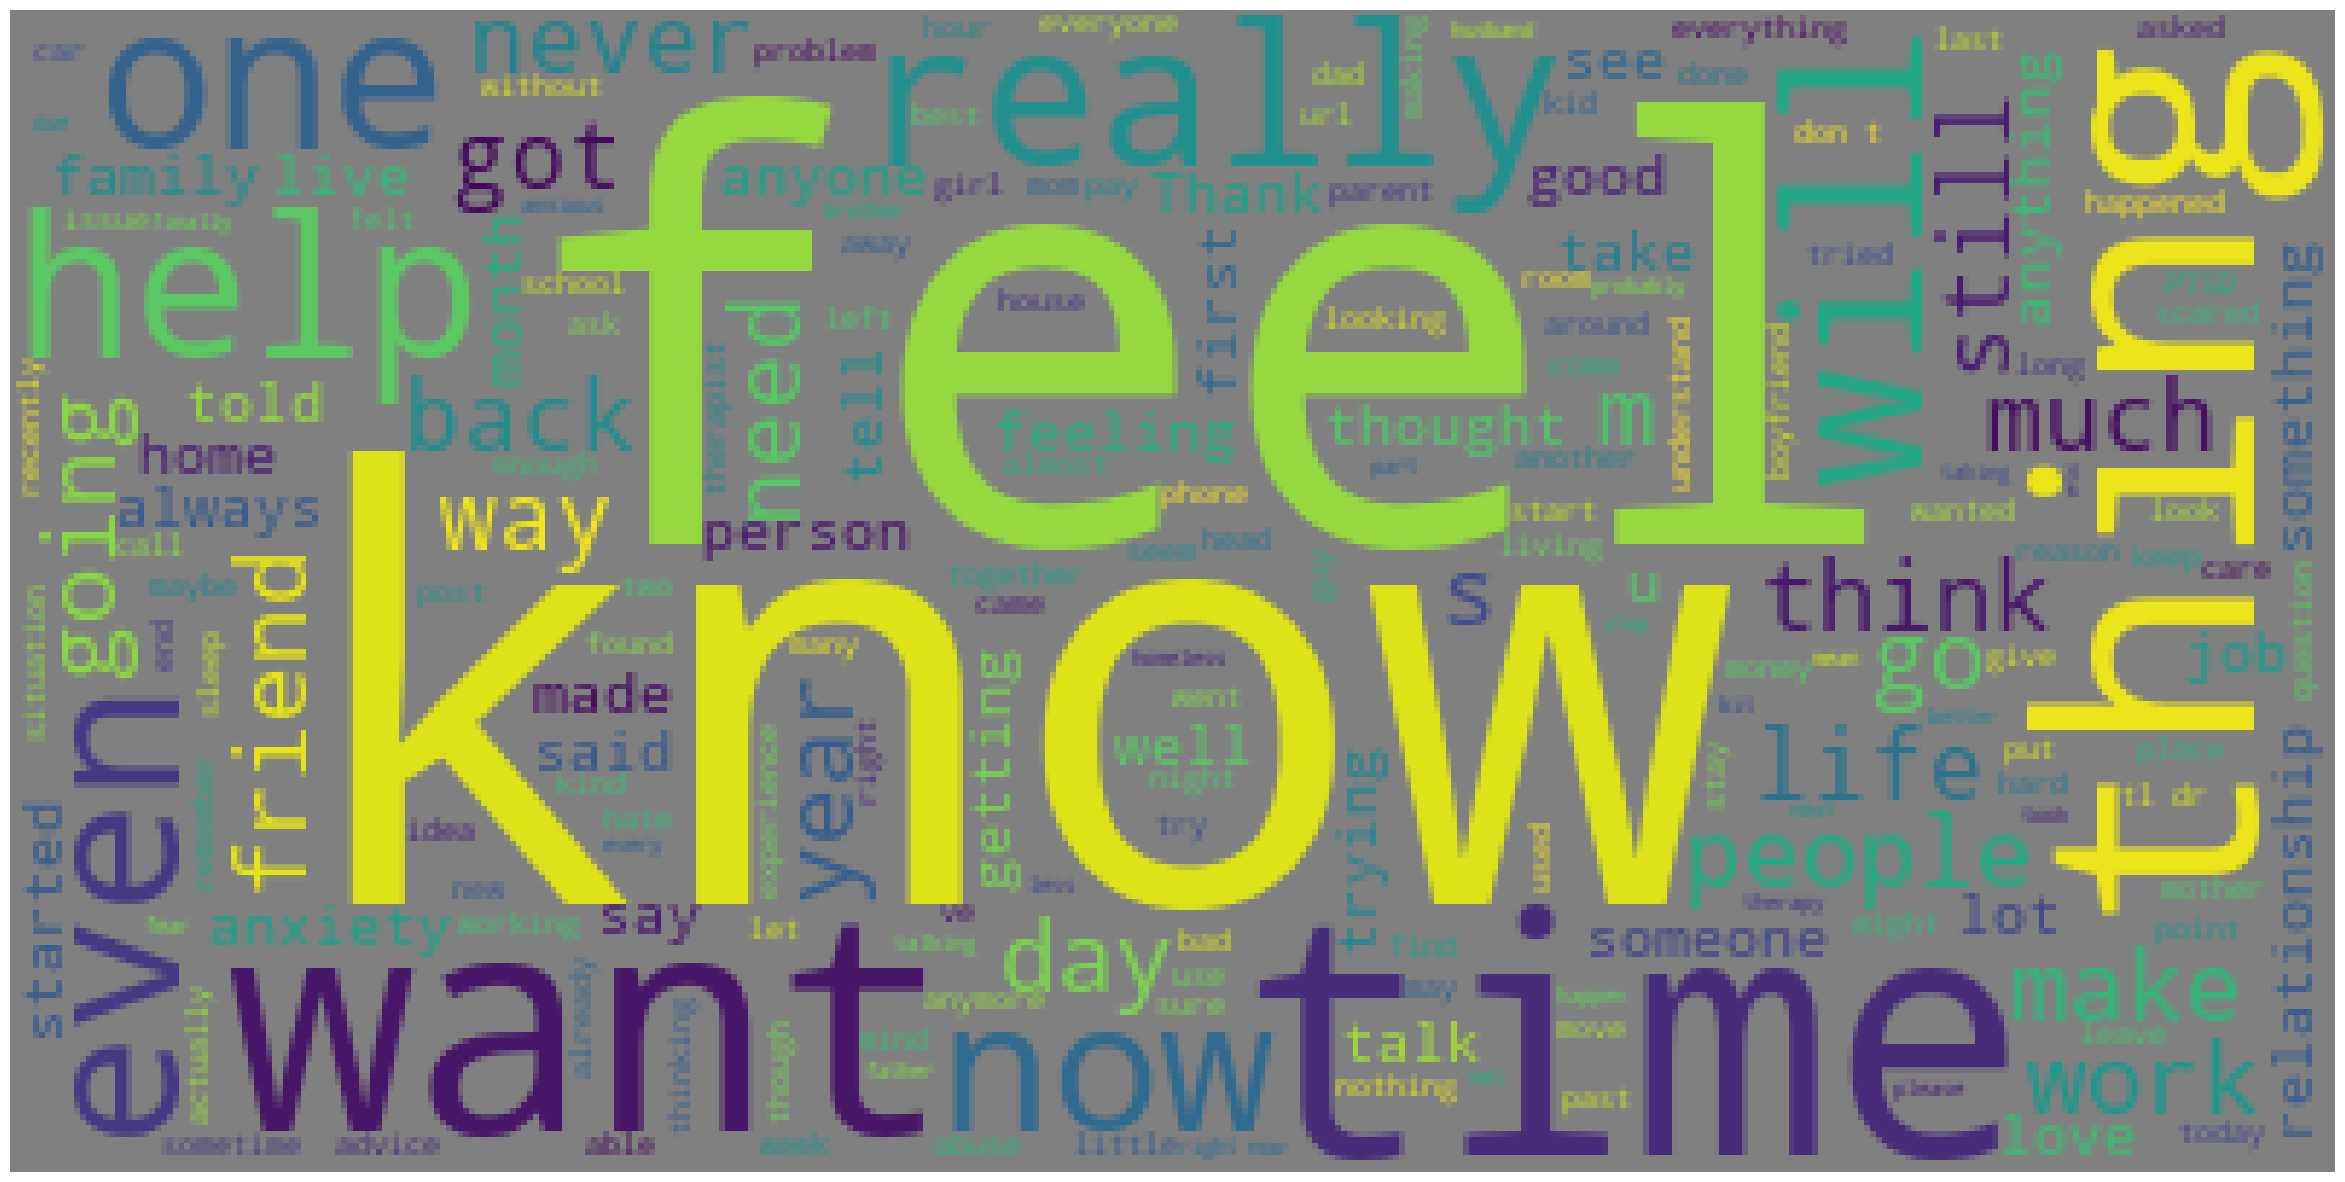

In [59]:
X_train_multimodal.shape

(2128, 8318)

In [66]:
X_test_multimodal.shape

(710, 8318)

In [67]:
assert X_train_multimodal.shape[1] == X_test_multimodal.shape[1]

In [49]:
#Adding meaning to text from og dataset
train["meaning"] = train["label"].map({0:"Unstressed", 1:"Stressed"})


In [50]:
value_counts = train["meaning"].value_counts()

<Axes: xlabel='meaning'>

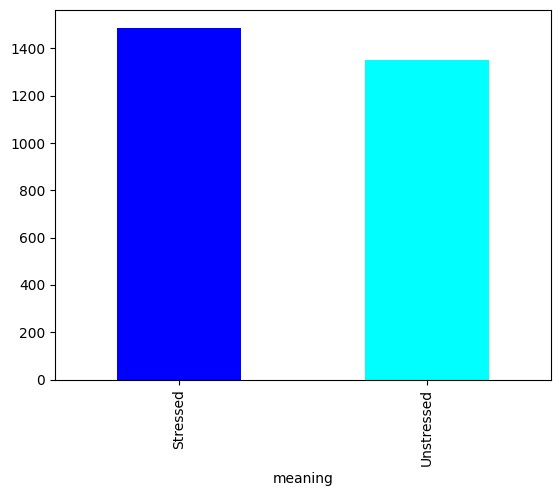

In [51]:
value_counts.plot(kind='bar', color=['blue', 'cyan'])



In [54]:
numerical_columns + ["text"]

['lex_liwc_Tone',
 'lex_liwc_negemo',
 'lex_liwc_Clout',
 'lex_liwc_i',
 'sentiment',
 'text']

In [55]:
# y = posts["meaning"]
# y = train['label']


In [69]:
X_train_text_only, vect = process_categorical_features(X_train)


/tmp/ipykernel_22/1075191487.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  posts["text"] = posts["text"].apply(removal)


In [70]:
X_test_text_only, _ = process_categorical_features(X_test, vect)

/tmp/ipykernel_22/1075191487.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  posts["text"] = posts["text"].apply(removal)


In [71]:
X_train_text_only.shape

(2128, 8313)

In [72]:
X_test_text_only.shape

(710, 8313)

In [73]:
# X_text_features.toarray().shape

In [47]:
# x_train_combined,x_test_combined,y_train,y_test=train_test_split(X_combined,y,random_state=43)


Note that I preprocessed the data after splitting. You should not preprocess before splitting as this causes data leakage from the test data into the train data. Ideally, you do not touch your test data during training.

In [48]:
# X_combined.shape

(2838, 9453)

In [49]:
# X_text_features

In [50]:
# x_train_text,x_test_text,y_train,y_test=train_test_split(X_text_features.toarray(),y,random_state=43)

In [75]:
# x_train_combined

In [76]:
mb=MultinomialNB()
mb.fit(X_train_text_only,y_train)
y_pred= mb.predict(X_test_text_only)

print(f"Model Accuracy for Naive Bayes for text input is {round (accuracy_score(y_pred,y_test)*100, 2)}%")



Model Accuracy for Naive Bayes for text input is 70.7%


The MultinomialNB model does not accept negative values, therefore, this was not used on the combined data

In [79]:

logistic_reg =LogisticRegression().fit(X_train_text_only, y_train)
y_pred= logistic_reg.predict(X_test_text_only)
print(f"Model Accuracy for logistic regression is {round (accuracy_score(y_pred,y_test)*100, 2)}%")

Model Accuracy for logistic regression is 68.17%


In [80]:
logistic_reg =LogisticRegression(max_iter=1000).fit(X_train_multimodal, y_train)
y_pred= logistic_reg.predict(X_test_multimodal)
print(f"Model Accuracy for logistic regression for multimodal input is {round (accuracy_score(y_pred,y_test)*100, 2)}%")

Model Accuracy for logistic regression for multimodal input is 71.13%


In [81]:

tree=DecisionTreeClassifier()
tree.fit(X_train_text_only,y_train)
y_pred=tree.predict(X_test_text_only)
print(f"Model Accuracy for Decision Tree for text input is is {round (accuracy_score(y_test,y_pred)*100, 2)}%")

Model Accuracy for Decision Tree for text input is is 64.37%


In [82]:
tree=DecisionTreeClassifier()
tree.fit(X_train_multimodal,y_train)
y_pred=tree.predict(X_test_multimodal)
print(f"Model Accuracy for Decision Tree multimodal input is {round (accuracy_score(y_test,y_pred)*100, 2)}%")

Model Accuracy for Decision Tree multimodal input is 66.2%


In [87]:
clf = GaussianNB()
clf.fit(X_train_text_only.toarray(), y_train)
y_pred=clf.predict(X_test_text_only.toarray())
print(f"Model Accuracy for Gaussian Naive Bayes for text input is {round (accuracy_score(y_test,y_pred)*100, 2)}%")

Model Accuracy for Gaussian Naive Bayes for text input is 62.11%


In [88]:
clf = GaussianNB()
clf.fit(X_train_multimodal,y_train)
y_pred=clf.predict(X_test_multimodal)
print(f"Model Accuracy for Gaussian Naive Bayes for multimodal input is {round (accuracy_score(y_test,y_pred)*100, 2)}%")


Model Accuracy for Gaussian Naive Bayes for multimodal input is 62.11%


In [89]:
# Create Random Forest classifier
clf_rf = RandomForestClassifier(n_estimators=100, random_state=42)

# Fit the classifier on the training data
clf_rf.fit(X_train_text_only, y_train)

# Make predictions on the test data
y_pred_rf = clf_rf.predict(X_test_text_only)

# Evaluate accuracy of the classifier
accuracy_rf = round (accuracy_score(y_pred_rf,y_test)*100, 2)
print(f"Model Accuracy for Random Forest for text input: {accuracy_rf} %" )

Model Accuracy for Random Forest for text input: 66.2 %


In [90]:
# Create Random Forest classifier
clf_rf = RandomForestClassifier(n_estimators=100, random_state=42)

# Fit the classifier on the training data
clf_rf.fit(X_train_multimodal, y_train)

# Make predictions on the test data
y_pred_rf = clf_rf.predict(X_test_multimodal)

# Evaluate accuracy of the classifier
accuracy_rf = round (accuracy_score(y_pred_rf,y_test)*100, 2)
print(f"Model Accuracy for Random Forest Accuracy for input is: {accuracy_rf} %" )



Model Accuracy for Random Forest Accuracy for input is: 73.1 %


In [91]:
clf_xgb = XGBClassifier(n_estimators=100, random_state=42)

# Fit the classifier on the training data
clf_xgb.fit(X_train_text_only, y_train)

# Make predictions on the test data
y_pred_xgb = clf_xgb.predict(X_test_text_only)

# Evaluate accuracy of the classifier
accuracy_xgb = round (accuracy_score(y_pred_xgb,y_test)*100, 2)
print(f"Model accuracy for XGBoost for text input: {accuracy_xgb} %" )

Model accuracy for XGBoost for text input: 66.76 %


In [92]:
clf_xgb = XGBClassifier(n_estimators=100, random_state=42)

# Fit the classifier on the training data
clf_xgb.fit(X_train_multimodal, y_train)

# Make predictions on the test data
y_pred_xgb = clf_xgb.predict(X_test_multimodal)

# Evaluate accuracy of the classifier
accuracy_xgb = round (accuracy_score(y_pred_xgb,y_test)*100, 2)
print(f"Model Accuracy for XGBoost for multimodal input: {accuracy_xgb} %" )

Model Accuracy for XGBoost for multimodal input: 73.24 %


Although XGBoost using multimodal input was the best performing model after revamping the code and fixing data leakage issues, Random Forest was initially used in the earlier experimentation. It is to be noted that model deployment and monitoring was the key aspect of the project.